#### Imports

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping
import optuna
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

c:\Users\atuls\ownCloud - yashsingh@oc.lookwhatsaround.me\Documents\Fantasy Football Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Starting Connection and Querying Data from Supabase

In [2]:
# Load environment variables from .env
load_dotenv()

# Fetch variables
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)
# If using Transaction Pooler or Session Pooler, we want to ensure we disable SQLAlchemy client side pooling -
# https://docs.sqlalchemy.org/en/20/core/pooling.html#switching-pool-implementations
# engine = create_engine(DATABASE_URL, poolclass=NullPool)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

Connection successful!


In [3]:
query = """
SELECT *
FROM "WRTEPointProjection"
WHERE season BETWEEN 2018 AND 2024
"""

wrte_df = pd.read_sql(query, engine)

print(wrte_df.shape)
wrte_df.head()

(24797, 43)


,player_id,player_name,team,season,week,opponent_team,fantasy_points_ppr,targets_prev,receptions_prev,receiving_yards_prev,...,wrte_targets_allowed_roll3_mean,wrte_targets_allowed_roll5_mean,wrte_receptions_allowed_roll3_mean,wrte_receptions_allowed_roll5_mean,wrte_rec_yards_allowed_roll3_mean,wrte_rec_yards_allowed_roll5_mean,wrte_rec_tds_allowed_roll3_mean,wrte_rec_tds_allowed_roll5_mean,wrte_fp_allowed_roll3_mean,wrte_fp_allowed_roll5_mean
0,00-0021547,A.Gates,LAC,2018,1,KC,5.6,52.0,30.0,316.0,...,30.000000,29.75,16.000000,18.00,208.000000,225.50,1.000000,0.75,41.30,44.600
1,00-0021547,A.Gates,LAC,2018,2,BUF,0.0,52.0,30.0,316.0,...,26.000000,26.50,17.500000,16.25,212.000000,175.25,2.000000,1.25,51.30,41.925
2,00-0021547,A.Gates,LAC,2018,3,LA,7.5,52.0,30.0,316.0,...,21.500000,23.75,13.500000,13.50,157.500000,164.25,0.000000,0.25,29.70,31.150
3,00-0021547,A.Gates,LAC,2018,4,SF,10.7,52.0,30.0,316.0,...,30.000000,31.75,17.333333,18.50,240.666667,254.50,2.666667,2.50,58.80,60.500
4,00-0021547,A.Gates,LAC,2018,5,LV,3.9,52.0,30.0,316.0,...,28.333333,27.75,16.666667,15.75,263.666667,241.75,2.000000,1.75,57.06,52.645


In [4]:
wrte_df['atleast10'] = wrte_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 10.0 else 0)
wrte_df['atleast15'] = wrte_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 15.0 else 0)
wrte_df['atleast20'] = wrte_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 20.0 else 0)

#### 10 Point Probability Model

#### Building Feature and Target Set

In [5]:
TARGET = "atleast10"

keys_df = wrte_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast20", "atleast15", 'fantasy_points_ppr', TARGET]
X = wrte_df.drop(columns=[c for c in drop_cols if c in wrte_df.columns]).copy()
y = wrte_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (24797, 35) y shape: (24797,)


#### Building Training, Validation, and Testing Set

In [6]:
train_mask = wrte_df["season"].between(2018, 2022)
val_mask   = wrte_df["season"].eq(2023)
test_mask  = wrte_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)

print(X_train.shape, X_val.shape, X_test.shape)

(17476, 35) (3661, 35) (3660, 35)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [8]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 4816, number of negative: 12660
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3295
[LightGBM] [Info] Number of data points in the train set: 17476, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275578 -> initscore=-0.966504
[LightGBM] [Info] Start training from score -0.966504
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [9]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.50
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [10]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.7995083310570882
Precision: 0.6486928104575164
Recall: 0.4334061135371179
F1 Score: 0.5196335078534031
ROC-AUC: 0.8216554911271785


Test Metrics
Accuracy: 0.7931693989071038
Precision: 0.6440422322775264
Recall: 0.45042194092827004
F1 Score: 0.5301055245189323
ROC-AUC: 0.8245996851001333


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

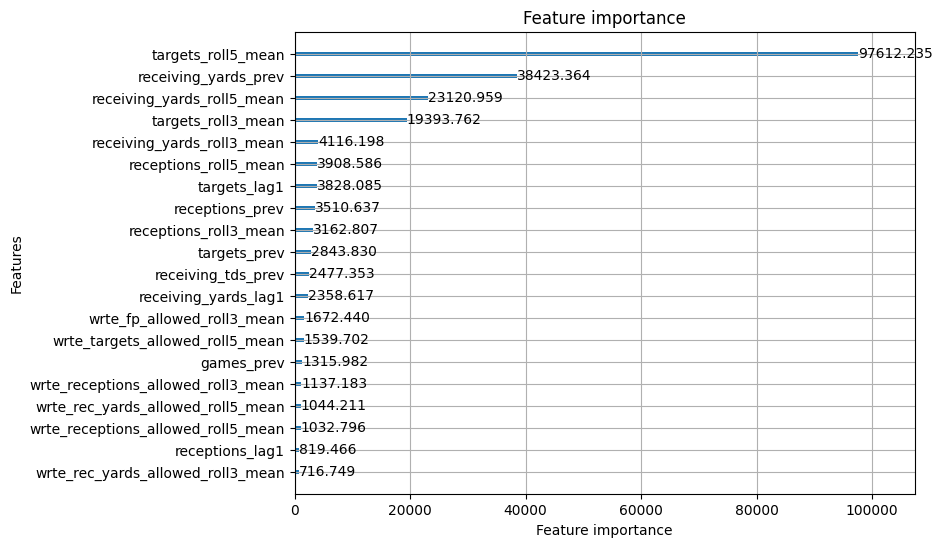

In [11]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [12]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast10"] = val_proba
val_preds_df["pred_atleast10"] = val_pred
val_preds_df["true_atleast10"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast10,pred_atleast10,true_atleast10
0,00-0024243,M.Lewis,2023,4,CHI,DEN,0.091493,0,0
1,00-0024243,M.Lewis,2023,7,CHI,LV,0.082511,0,0
2,00-0024243,M.Lewis,2023,8,CHI,LAC,0.099559,0,0
3,00-0024243,M.Lewis,2023,11,CHI,DET,0.067495,0,0
4,00-0024243,M.Lewis,2023,14,CHI,DET,0.060261,0,0
5,00-0024243,M.Lewis,2023,16,CHI,ARI,0.039367,0,0
6,00-0026293,M.Slater,2023,4,NE,DAL,0.070426,0,0
7,00-0026293,M.Slater,2023,5,NE,NO,0.023015,0,0
8,00-0026293,M.Slater,2023,14,NE,PIT,0.022707,0,0
9,00-0026293,M.Slater,2023,17,NE,BUF,0.020217,0,0


#### 15 Point Probability Model

#### Building Feature and Target Set

In [13]:
TARGET = "atleast15"

keys_df = wrte_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast10", "atleast20", 'fantasy_points_ppr', TARGET]
X = wrte_df.drop(columns=[c for c in drop_cols if c in wrte_df.columns]).copy()
y = wrte_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (24797, 35) y shape: (24797,)


#### Building Training, Validation, and Testing Set

In [14]:
train_mask = wrte_df["season"].between(2018, 2022)
val_mask   = wrte_df["season"].eq(2023)
test_mask  = wrte_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [ ]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

In [17]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.50
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [18]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.8686151324774651
Precision: 0.625
Recall: 0.030800821355236138
F1 Score: 0.05870841487279843
ROC-AUC: 0.8368510704918946


Test Metrics
Accuracy: 0.8592896174863388
Precision: 0.5
Recall: 0.021359223300970873
F1 Score: 0.040968342644320296
ROC-AUC: 0.835044993594394


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

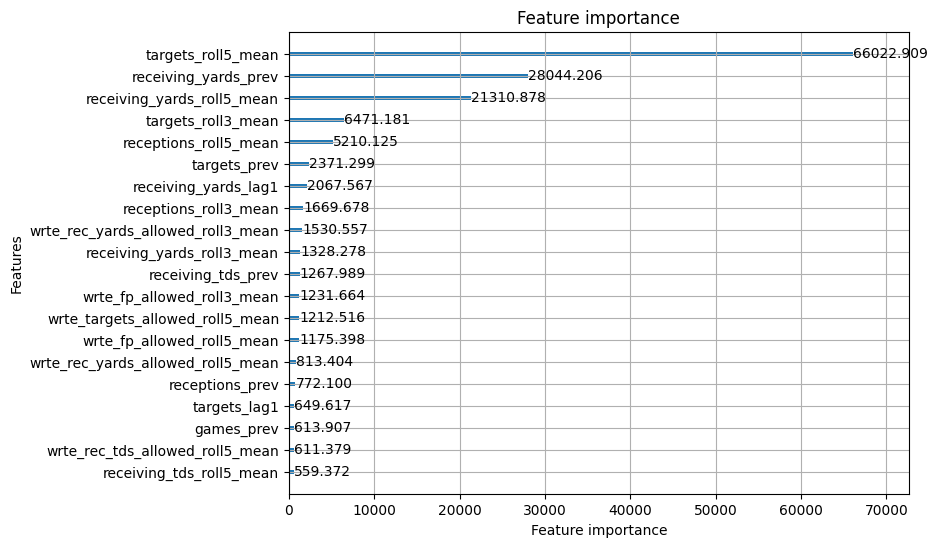

In [19]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [20]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast15"] = val_proba
val_preds_df["pred_atleast15"] = val_pred
val_preds_df["true_atleast15"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast15,pred_atleast15,true_atleast15
0,00-0024243,M.Lewis,2023,4,CHI,DEN,0.054447,0,0
1,00-0024243,M.Lewis,2023,7,CHI,LV,0.047749,0,0
2,00-0024243,M.Lewis,2023,8,CHI,LAC,0.051309,0,0
3,00-0024243,M.Lewis,2023,11,CHI,DET,0.050784,0,0
4,00-0024243,M.Lewis,2023,14,CHI,DET,0.050784,0,0
5,00-0024243,M.Lewis,2023,16,CHI,ARI,0.049165,0,0
6,00-0026293,M.Slater,2023,4,NE,DAL,0.053983,0,0
7,00-0026293,M.Slater,2023,5,NE,NO,0.046287,0,0
8,00-0026293,M.Slater,2023,14,NE,PIT,0.046287,0,0
9,00-0026293,M.Slater,2023,17,NE,BUF,0.046287,0,0


#### 20 Point Probability

#### Building Feature and Target Set

In [21]:
TARGET = "atleast20"

keys_df = wrte_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast10", "atleast15", 'fantasy_points_ppr', TARGET]
X = wrte_df.drop(columns=[c for c in drop_cols if c in wrte_df.columns]).copy()
y = wrte_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (24797, 35) y shape: (24797,)


#### Building Training, Validation, and Testing Set

In [22]:
train_mask = wrte_df["season"].between(2018, 2022)
val_mask   = wrte_df["season"].eq(2023)
test_mask  = wrte_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [24]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 1215, number of negative: 16261
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3295
[LightGBM] [Info] Number of data points in the train set: 17476, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069524 -> initscore=-2.594026
[LightGBM] [Info] Start training from score -2.594026
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [25]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.3
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [26]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.9289811526905217
Precision: 0.35714285714285715
Recall: 0.15086206896551724
F1 Score: 0.21212121212121213
ROC-AUC: 0.8446905702879093


Test Metrics
Accuracy: 0.9275956284153005
Precision: 0.3384615384615385
Recall: 0.09016393442622951
F1 Score: 0.1423948220064725
ROC-AUC: 0.8379803816178446


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

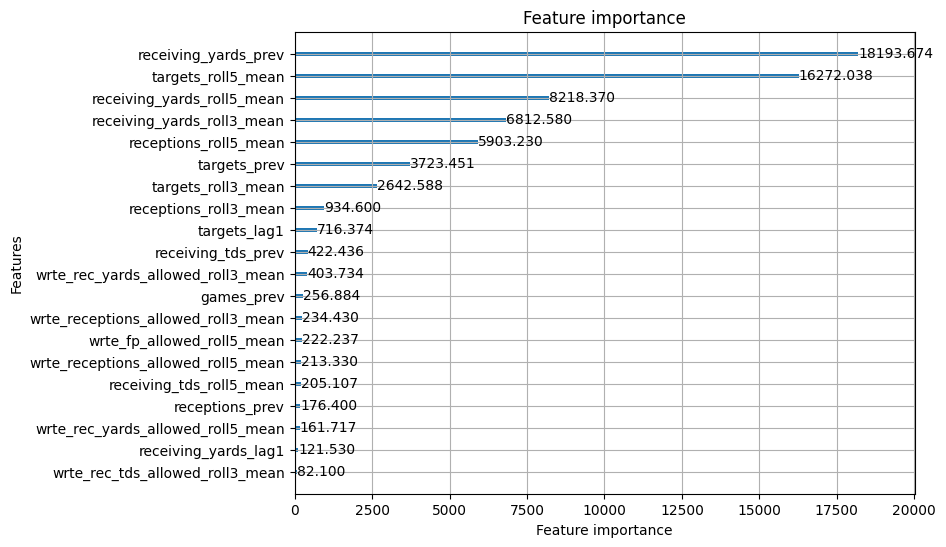

In [27]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [28]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast20"] = val_proba
val_preds_df["pred_atleast20"] = val_pred
val_preds_df["true_atleast20"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast20,pred_atleast20,true_atleast20
0,00-0024243,M.Lewis,2023,4,CHI,DEN,0.019233,0,0
1,00-0024243,M.Lewis,2023,7,CHI,LV,0.009218,0,0
2,00-0024243,M.Lewis,2023,8,CHI,LAC,0.009287,0,0
3,00-0024243,M.Lewis,2023,11,CHI,DET,0.009218,0,0
4,00-0024243,M.Lewis,2023,14,CHI,DET,0.009218,0,0
5,00-0024243,M.Lewis,2023,16,CHI,ARI,0.009218,0,0
6,00-0026293,M.Slater,2023,4,NE,DAL,0.012688,0,0
7,00-0026293,M.Slater,2023,5,NE,NO,0.009218,0,0
8,00-0026293,M.Slater,2023,14,NE,PIT,0.009218,0,0
9,00-0026293,M.Slater,2023,17,NE,BUF,0.009218,0,0
